# NQ Intraday Research Notebook

## 1) Setup projet

In [1]:
from pathlib import Path
import sys
root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))
print("Project root set to:", root)


Project root set to: C:\Donnees\Business\Trading\Code\algo-trading-intraday-research


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config.paths import RAW_DATA_DIR, ensure_directories
from src.data.loader import load_ohlcv_csv
from src.data.validation import validate_ohlcv
from src.data.cleaning import clean_ohlcv
from src.data.session import extract_rth, add_session_date
from src.features.intraday import add_intraday_features
from src.features.opening_range import compute_opening_range
from src.features.returns import add_simple_returns, add_log_returns
from src.features.volatility import add_rolling_std, add_atr
from src.strategy.orb import ORBStrategy
from src.engine.execution_model import ExecutionModel
from src.engine.backtester import run_backtest
from src.engine.portfolio import build_equity_curve
from src.analytics.metrics import compute_metrics
from src.analytics.diagnostics import performance_by_weekday, performance_by_month, performance_by_year
from src.analytics.heatmaps import run_orb_grid_search, pivot_heatmap
from src.visualization.plots import plot_trade_histogram, plot_pnl_distribution, plot_cumulative_pnl
from src.visualization.equity import plot_equity_curve, plot_drawdown_curve

ensure_directories()
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)

## 2) Chargement d’un sample 1-minute

In [3]:
# api_key = 'xxx'

# import databento as db

# # Connexion au service historical
# client = db.Historical(api_key)

# # Récupération du MNQ front month en bougies 1 minute
# data = client.timeseries.get_range(
#     dataset="GLBX.MDP3",      # CME Globex MDP 3.0
#     symbols="MNQ.v.0",        # MNQ continuous front month
#     stype_in="continuous",
#     schema="ohlcv-1m",
#     start="2015-01-01T00:00:00Z",
#     end="2026-03-03T0:00:00Z",
# )

# # Conversion en DataFrame pandas
# df = data.to_df()

In [4]:
# df.to_csv(RAW_DATA_DIR / 'MNQ_1mim.parquet')

In [7]:
df_raw = load_ohlcv_csv(RAW_DATA_DIR / 'MNQ_1mim.csv')
df_raw.head()

KeyError: 'ts_event'

## 3) Contrôle qualité de la donnée

In [83]:
quality_report = validate_ohlcv(df_raw)
quality_report

QualityReport(rows=2996, missing_required_columns=[], is_chronological=True, duplicate_timestamps=0, invalid_ohlc_rows=0, negative_volume_rows=0)

## 4) Nettoyage

In [84]:
df = clean_ohlcv(df_raw)
len(df), df.head()

(2996,
                   timestamp      open      high      low     close  volume
 0 2026-02-15 18:00:00-05:00  24789.75  24834.75  24766.0  24775.25    1720
 1 2026-02-15 18:05:00-05:00  24776.00  24780.00  24754.5  24770.50     842
 2 2026-02-15 18:10:00-05:00  24770.75  24800.00  24769.5  24800.00     577
 3 2026-02-15 18:15:00-05:00  24798.50  24825.75  24795.0  24821.00     704
 4 2026-02-15 18:20:00-05:00  24822.25  24825.00  24804.0  24819.50     518)

## 5) Filtrage de session (RTH)

In [85]:
df_rth = extract_rth(df)
df_rth = add_session_date(df_rth)
df_rth[['timestamp', 'session_date']].head()

,timestamp,session_date
0,2026-02-16 09:30:00-05:00,2026-02-16
1,2026-02-16 09:35:00-05:00,2026-02-16
2,2026-02-16 09:40:00-05:00,2026-02-16
3,2026-02-16 09:45:00-05:00,2026-02-16
4,2026-02-16 09:50:00-05:00,2026-02-16


## 6) Construction de features intraday

In [86]:
df_feat = add_intraday_features(df_rth)
df_feat = add_simple_returns(df_feat)
df_feat = add_log_returns(df_feat)
df_feat = add_rolling_std(df_feat, window=5)
df_feat = add_atr(df_feat, window=5)
df_feat.head()

,timestamp,open,high,low,close,volume,session_date,minute_of_day,weekday,bar_in_session,ret_simple,ret_log,vol_std_5,atr_5
0,2026-02-16 09:30:00-05:00,24762.75,24776.5,24746.00,24757.50,2995,2026-02-16,570,0,1,NaN,NaN,NaN,NaN
1,2026-02-16 09:35:00-05:00,24756.75,24769.5,24730.00,24731.00,2791,2026-02-16,575,0,2,-0.001070,-0.001071,NaN,NaN
2,2026-02-16 09:40:00-05:00,24732.50,24745.5,24711.50,24723.25,2407,2026-02-16,580,0,3,-0.000313,-0.000313,NaN,NaN
3,2026-02-16 09:45:00-05:00,24723.50,24731.0,24692.75,24727.25,2821,2026-02-16,585,0,4,0.000162,0.000162,NaN,NaN
4,2026-02-16 09:50:00-05:00,24729.00,24759.0,24728.75,24754.00,2052,2026-02-16,590,0,5,0.001082,0.001081,NaN,NaN


## 7) Calcul de l’opening range

In [97]:
or_minutes=5
df_or = compute_opening_range(df_feat, or_minutes=or_minutes)
df_or[['timestamp', 'session_date', 'or_high', 'or_low', 'or_width', 'or_midpoint']].head(10)

,timestamp,session_date,or_high,or_low,or_width,or_midpoint
0,2026-02-16 09:30:00-05:00,2026-02-16,24776.5,24746.0,30.5,24761.25
1,2026-02-16 09:35:00-05:00,2026-02-16,24776.5,24746.0,30.5,24761.25
2,2026-02-16 09:40:00-05:00,2026-02-16,24776.5,24746.0,30.5,24761.25
3,2026-02-16 09:45:00-05:00,2026-02-16,24776.5,24746.0,30.5,24761.25
4,2026-02-16 09:50:00-05:00,2026-02-16,24776.5,24746.0,30.5,24761.25
5,2026-02-16 09:55:00-05:00,2026-02-16,24776.5,24746.0,30.5,24761.25
6,2026-02-16 10:00:00-05:00,2026-02-16,24776.5,24746.0,30.5,24761.25
7,2026-02-16 10:05:00-05:00,2026-02-16,24776.5,24746.0,30.5,24761.25
8,2026-02-16 10:10:00-05:00,2026-02-16,24776.5,24746.0,30.5,24761.25
9,2026-02-16 10:15:00-05:00,2026-02-16,24776.5,24746.0,30.5,24761.25


In [107]:
df_or

,timestamp,open,high,low,close,volume,session_date,minute_of_day,weekday,bar_in_session,ret_simple,ret_log,vol_std_5,atr_5,or_high,or_low,or_width,or_midpoint
0,2026-02-16 09:30:00-05:00,24762.75,24776.50,24746.00,24757.50,2995,2026-02-16,570,0,1,NaN,NaN,NaN,NaN,24776.50,24746.0,30.50,24761.250
1,2026-02-16 09:35:00-05:00,24756.75,24769.50,24730.00,24731.00,2791,2026-02-16,575,0,2,-0.001070,-0.001071,NaN,NaN,24776.50,24746.0,30.50,24761.250
2,2026-02-16 09:40:00-05:00,24732.50,24745.50,24711.50,24723.25,2407,2026-02-16,580,0,3,-0.000313,-0.000313,NaN,NaN,24776.50,24746.0,30.50,24761.250
3,2026-02-16 09:45:00-05:00,24723.50,24731.00,24692.75,24727.25,2821,2026-02-16,585,0,4,0.000162,0.000162,NaN,NaN,24776.50,24746.0,30.50,24761.250
4,2026-02-16 09:50:00-05:00,24729.00,24759.00,24728.75,24754.00,2052,2026-02-16,590,0,5,0.001082,0.001081,NaN,NaN,24776.50,24746.0,30.50,24761.250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,2026-03-02 15:40:00-05:00,25002.25,25013.00,24974.50,25008.75,3070,2026-03-02,940,0,75,0.000260,0.000260,0.000926,39.20,24849.75,24605.0,244.75,24727.375
828,2026-03-02 15:45:00-05:00,25008.00,25030.00,24996.50,25011.75,5593,2026-03-02,945,0,76,0.000120,0.000120,0.000806,38.20,24849.75,24605.0,244.75,24727.375
829,2026-03-02 15:50:00-05:00,25012.25,25045.25,25008.50,25040.75,5670,2026-03-02,950,0,77,0.001159,0.001159,0.000719,38.35,24849.75,24605.0,244.75,24727.375
830,2026-03-02 15:55:00-05:00,25041.75,25062.75,25019.00,25023.25,13176,2026-03-02,955,0,78,-0.000699,-0.000699,0.000675,37.50,24849.75,24605.0,244.75,24727.375


## 8) Backtest ORB baseline

In [114]:
strategy = ORBStrategy(
    or_minutes=or_minutes,
    direction='both',
    one_trade_per_day=True,
    entry_buffer_ticks=0,
    stop_multiple=1.0,
    target_multiple=3.0,
    time_exit='16:00:00',
    account_size_usd=50_000,
    risk_per_trade_pct=1.0,
)
df_sig = strategy.generate_signals(df_or)
trades = run_backtest(
    df_sig,
    execution_model=ExecutionModel(),
    time_exit=strategy.time_exit,
    stop_multiple=strategy.stop_multiple,
    target_multiple=strategy.target_multiple,
    account_size_usd=strategy.account_size_usd,
    risk_per_trade_pct=strategy.risk_per_trade_pct,
)
trades[[
    'session_date',
    'direction',
    'quantity',
    'risk_budget_usd',
    'actual_risk_usd',
    'net_pnl_usd',
]]

KeyboardInterrupt: 

## 9) Analyse des trades

In [99]:
metrics = compute_metrics(trades)
metrics

{'n_trades': 0,
 'win_rate': 0.0,
 'avg_win': 0.0,
 'avg_loss': 0.0,
 'expectancy': 0.0,
 'profit_factor': 0.0,
 'cumulative_pnl': 0.0,
 'max_drawdown': 0.0}

In [100]:
performance_by_weekday(trades)

,index,weekday,count,sum,mean


In [101]:
performance_by_month(trades)

,index,month,count,sum,mean


In [102]:
performance_by_year(trades)

,index,year,count,sum,mean


## 10) Equity curve

In [103]:
equity = build_equity_curve(trades, initial_capital=strategy.account_size_usd or 100_000.0)
equity.head()

,timestamp,equity,drawdown


In [104]:
if not trades.empty:
    plot_trade_histogram(trades)
    plot_pnl_distribution(trades)
    plot_cumulative_pnl(trades)
    plot_equity_curve(equity)
    plot_drawdown_curve(equity)
    plt.show()

## 11) Exemple de mini grid search

In [105]:
grid = run_orb_grid_search(df_or, or_minutes_values=[5, 15, 30, 60], target_multiple_values=[1.0, 2.0, 3.0, 5.0, 10.0])
grid

,or_minutes,target_multiple,cumulative_pnl,win_rate,n_trades
0,5,1.0,5852.5,0.636364,11
1,5,2.0,12672.5,0.545455,11
2,5,3.0,16297.5,0.545455,11
3,5,5.0,13532.5,0.545455,11
4,5,10.0,13532.5,0.545455,11
5,15,1.0,5852.5,0.636364,11
6,15,2.0,12672.5,0.545455,11
7,15,3.0,16297.5,0.545455,11
8,15,5.0,13532.5,0.545455,11
9,15,10.0,13532.5,0.545455,11


## 12) Heatmap simple

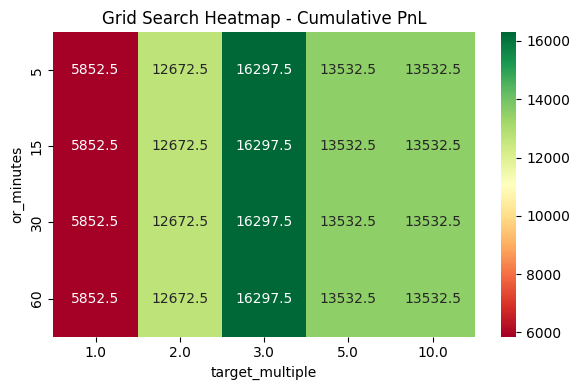

In [106]:
heatmap_df = pivot_heatmap(grid, index='or_minutes', columns='target_multiple', values='cumulative_pnl')
plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_df, annot=True, fmt='.1f', cmap='RdYlGn')
plt.title('Grid Search Heatmap - Cumulative PnL')
plt.tight_layout()
plt.show()

## 13) Next steps

- Remplacer les CSV samples par historique complet Bloomberg/futures.
- Ajouter découpage in-sample / out-of-sample et walk-forward.
- Ajouter stress tests coûts/slippage et filtres de volatilité.
- Préparer une couche broker/exécution live avec risk checks.